# Лабораторная работа №2

Задача: классификация цветов автомобилей

Ход работы:
1. Написать своими руками классификатор (ResNet) и обучить его на датасете DVM (фронтальный вид)
2. Взять аналогичный классификатор, предобученный на ImageNet, и дообучить на собранном датасете
3. Оценить результат. Оценка качества производится при помощи F1_macro, требуется получить F1_macro > 0.8
4. Сравнить полученное качество и сделать вывод

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision.models import resnet18, ResNet18_Weights
from torch.utils.data import DataLoader, Dataset, Subset
from torchvision import transforms

import os
import json
from PIL import Image
from collections import Counter

import numpy as np
import pandas as pd
from tqdm import tqdm
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score, classification_report, confusion_matrix


device = torch.device('cuda' if torch.cuda.is_available() else 'mps')
print(f'Используемое устройство: {device}')

Используемое устройство: mps


## Part 1. Загрузка и подготовка датасета DVM

### Скачиваем данные датасета

In [2]:
!wget -O data.zip "https://ndownloader.figshare.com/files/34792480"
!unzip data.zip

Выходные данные были обрезаны до нескольких последних строк (5000).
  inflating: confirmed_fronts/Volkswagen/2008/Volkswagen$$Tiguan$$2008$$Black$$95_26$$559$$image_4.jpg  
  inflating: confirmed_fronts/Volkswagen/2008/Volkswagen$$Tiguan$$2008$$Grey$$95_26$$742$$image_0.jpg  
  inflating: confirmed_fronts/Volkswagen/2008/Volkswagen$$Touareg$$2008$$Black$$95_28$$333$$image_5.jpg  
  inflating: confirmed_fronts/Volkswagen/2008/Volkswagen$$Touareg$$2008$$Grey$$95_28$$269$$image_5.jpg  
  inflating: confirmed_fronts/Volkswagen/2008/Volkswagen$$Touareg$$2008$$Silver$$95_28$$563$$image_5.jpg  
  inflating: confirmed_fronts/Volkswagen/2008/Volkswagen$$Touran$$2008$$Grey$$95_29$$1397$$image_5.jpg  
  inflating: confirmed_fronts/Volkswagen/2008/Volkswagen$$Touran$$2008$$Grey$$95_29$$48$$image_3.jpg  
  inflating: confirmed_fronts/Volkswagen/2008/Volkswagen$$Touran$$2008$$Unlisted$$95_29$$62$$image_1.jpg  
  inflating: confirmed_fronts/Volkswagen/2008/Volkswagen$$Transporter Shuttle$$2008$$Beige

### Описание датасета
DVM (Deep Visual Marketing) содержит изображения автомобилей для классификации по цвету. Мы используем фронтальный вид автомобилей.

In [4]:
class CarColorDataset(Dataset):

    def __init__(self, root_dir="confirmed_fronts", transform=None, min_samples=1600, verbose = False):
        self.root_dir = root_dir
        self.transform = transform
        self.min_samples = min_samples

        self.samples = []

        for root, dirs, files in os.walk(root_dir):
            for file in files:
                if not file.endswith(".jpg"):
                    continue

                parts = file.split("$$")
                if len(parts) < 4:
                    continue

                raw_color = parts[3]
                color = raw_color
                path = os.path.join(root, file)
                self.samples.append((path, color))

        color_counter = Counter(color for _, color in self.samples)

        self.valid_colors = {color for color, count in color_counter.items()
                            if count >= self.min_samples}

        self.samples = [(path, color) for path, color in self.samples
                       if color in self.valid_colors]

        self.colors = sorted(list(self.valid_colors))
        self.color_to_idx = {c: i for i, c in enumerate(self.colors)}

        if verbose :
            for color in self.colors:
                count = color_counter[color]
                print(f"Цвет {color}: {count} образцов")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, color = self.samples[idx]
        image = Image.open(img_path).convert("RGB")
        label = self.color_to_idx[color]

        if self.transform:
            image = self.transform(image)

        return image, label

### Определение трансформаций

In [5]:
IMG_SIZE = 224
BATCH_SIZE = 32

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.5),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

### Загрузка датасета и разделение на train/val/test

In [7]:
data_dir = '../../data/confirmed_fronts'

print(f"Классы:")
dataset = CarColorDataset(root_dir=data_dir, verbose=True)
num_classes = len(dataset.colors)

print(f"\nКолво классов: {num_classes}")

Классы:
Цвет Black: 14317 образцов
Цвет Blue: 8483 образцов
Цвет Grey: 9474 образцов
Цвет Red: 6095 образцов
Цвет Silver: 7770 образцов
Цвет White: 9395 образцов

Колво классов: 6


In [8]:
torch.manual_seed(42)
train_size = int(0.7 * len(dataset))
val_size = int(0.15 * len(dataset))
test_size = len(dataset) - train_size - val_size

indices = list(range(len(dataset)))
np.random.shuffle(indices)

train_idx = indices[:train_size]
val_idx = indices[train_size:train_size + val_size]
test_idx = indices[train_size + val_size:]

train_dataset = Subset(CarColorDataset(data_dir, train_transform), train_idx)
val_dataset = Subset(CarColorDataset(data_dir, test_transform), val_idx)
test_dataset = Subset(CarColorDataset(data_dir, test_transform), test_idx)

print(f"Train: {len(train_dataset)} изображений")
print(f"Val: {len(val_dataset)} изображений")
print(f"Test: {len(test_dataset)} изображений")

Train: 38873 изображений
Val: 8330 изображений
Test: 8331 изображений


### Создание DataLoader

In [10]:
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"Количество батчей в train: {len(train_loader)}")
print(f"Количество батчей в val: {len(val_loader)}")
print(f"Количество батчей в test: {len(test_loader)}")

Количество батчей в train: 1215
Количество батчей в val: 261
Количество батчей в test: 261


### Визуализация примеров из датасета

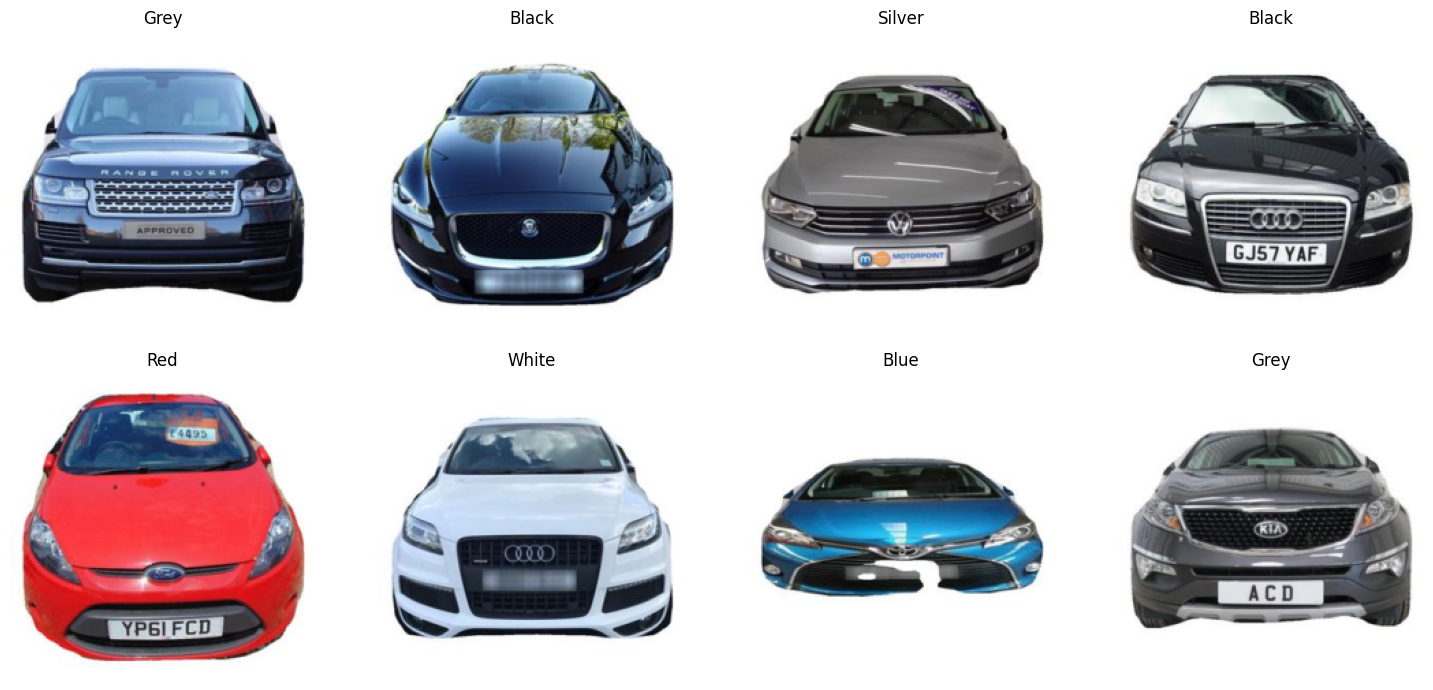

In [11]:
def denormalize(tensor):
    """Денормализация изображения"""
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
    return tensor * std + mean

idx_to_class = {v:k for k,v in dataset.color_to_idx.items()}

def show_samples(dataset, num_samples=8, use_base_indices=True):
    """
    Визуализация примеров из датасета

    Args:
        dataset: датасет или Subset
        num_samples: количество примеров для показа
        use_base_indices: если True, использует индексы из базового датасета,
                          чтобы избежать аугментаций при каждом вызове
    """
    if hasattr(dataset, "dataset"):
        base_dataset = dataset.dataset
        if use_base_indices:
            indices = np.random.choice(len(base_dataset), num_samples, replace=False)
        else:
            indices = np.random.choice(len(dataset), num_samples, replace=False)
    else:
        base_dataset = dataset
        indices = np.random.choice(len(dataset), num_samples, replace=False)

    vis_dataset = CarColorDataset(data_dir, test_transform)
    if hasattr(dataset, "dataset") and use_base_indices:
        actual_indices = indices
    elif hasattr(dataset, "dataset"):
        actual_indices = [dataset.indices[i] for i in indices]
    else:
        actual_indices = indices

    fig, axes = plt.subplots(2, 4, figsize=(15,7))
    axes = axes.flatten()

    for i, (idx, ax) in enumerate(zip(actual_indices, axes)):
        img, label_idx = vis_dataset[idx]

        img = denormalize(img)
        img = torch.clamp(img, 0, 1)

        label = idx_to_class[label_idx]

        ax.imshow(img.permute(1,2,0).numpy())
        ax.set_title(label)
        ax.axis("off")

    plt.tight_layout()
    plt.show()

vis_dataset = CarColorDataset(data_dir, test_transform)
show_samples(vis_dataset)

## Part 2. Реализация ResNet своими руками

### Базовый блок ResNet (BasicBlock)

In [12]:
class BasicBlock(nn.Module):
    """Базовый блок ResNet для ResNet-18/34"""
    expansion = 1

    def __init__(self, in_channels, out_channels, stride=1, downsample=None):
        super().__init__()

        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3,
                              stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)

        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3,
                              stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)

        self.downsample = downsample

    def forward(self, x):
        identity = x

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)

        if self.downsample is not None:
            identity = self.downsample(x)

        out += identity
        out = self.relu(out)

        return out

### Полная архитектура ResNet

In [13]:
class ResNet(nn.Module):
    """Кастомная реализация ResNet"""

    def __init__(self, block, layers, num_classes=10):
        super().__init__()

        self.in_channels = 64

        self.conv1 = nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)

        self.layer1 = self._make_layer(block, 64, layers[0])
        self.layer2 = self._make_layer(block, 128, layers[1], stride=2)
        self.layer3 = self._make_layer(block, 256, layers[2], stride=2)
        self.layer4 = self._make_layer(block, 512, layers[3], stride=2)

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512 * block.expansion, num_classes)

        self._initialize_weights()

    def _make_layer(self, block, out_channels, blocks, stride=1):
        downsample = None

        if stride != 1 or self.in_channels != out_channels * block.expansion:
            downsample = nn.Sequential(
                nn.Conv2d(self.in_channels, out_channels * block.expansion,
                          kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels * block.expansion)
            )

        layers_list = []
        layers_list.append(block(self.in_channels, out_channels, stride, downsample))
        self.in_channels = out_channels * block.expansion

        for _ in range(1, blocks):
            layers_list.append(block(self.in_channels, out_channels))

        return nn.Sequential(*layers_list)

    def _initialize_weights(self):
        """Инициализация весов для обучения с нуля"""
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
                nn.init.constant_(m.bias, 0)

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)

        return x


def ResNet18(num_classes=10):
    """ResNet-18: 4 слоя с [2, 2, 2, 2] блоками"""
    return ResNet(BasicBlock, [2, 2, 2, 2], num_classes=num_classes)


def ResNet34(num_classes=10):
    """ResNet-34: 4 слоя с [3, 4, 6, 3] блоками"""
    return ResNet(BasicBlock, [3, 4, 6, 3], num_classes=num_classes)

## Part 3. Функции для обучения и оценки

In [14]:
def train_epoch(model, dataloader, criterion, optimizer, device):
    """Обучение одной эпохи"""
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []

    for images, labels in tqdm(dataloader, desc="Training", leave=False):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * labels.size(0)
        predicted = torch.argmax(outputs, dim=1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    epoch_loss = running_loss / total
    epoch_acc = 100. * correct / total
    epoch_f1 = f1_score(all_labels, all_preds, average='macro')

    return epoch_loss, epoch_acc, epoch_f1

In [15]:
def validate(model, dataloader, criterion, device):
    """Валидация модели"""
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in tqdm(dataloader, desc="Validating", leave=False):
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * labels.size(0)
            predicted = torch.argmax(outputs, dim=1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    val_loss = running_loss / total
    val_acc = 100. * correct / total
    val_f1 = f1_score(all_labels, all_preds, average='macro')

    return val_loss, val_acc, val_f1, all_preds, all_labels

In [16]:
def train_model(model, train_loader, val_loader, num_epochs, device,
                lr=0.001, model_name="model"):
    """Полный цикл обучения модели"""
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min',
                                                       patience=3, factor=0.5)

    history = {
        'train_loss': [],
        'train_acc': [],
        'train_f1': [],
        'val_loss': [],
        'val_acc': [],
        'val_f1': []
    }

    best_f1 = 0.0
    best_epoch = 0

    for epoch in range(num_epochs):
        print(f"\nEpoch {epoch + 1}/{num_epochs}")
        print("-" * 50)

        train_loss, train_acc, train_f1 = train_epoch(
            model, train_loader, criterion, optimizer, device
        )

        val_loss, val_acc, val_f1, _, _ = validate(
            model, val_loader, criterion, device
        )

        scheduler.step(val_loss)

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['train_f1'].append(train_f1)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        history['val_f1'].append(val_f1)

        print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | Train F1: {train_f1:.4f}")
        print(f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}% | Val F1: {val_f1:.4f}")

        if val_f1 > best_f1:
            best_f1 = val_f1
            best_epoch = epoch + 1
            torch.save(model.state_dict(), f'best_{model_name}.pth')
            print(f"*** New best model saved! F1_macro: {best_f1:.4f} ***")

    print(f"\n{'='*50}")
    print(f"Training complete! Best Val F1_macro: {best_f1:.4f} at epoch {best_epoch}")
    print(f"{'='*50}")

    return history

In [17]:
def plot_history(history, model_name):
    """Визуализация истории обучения"""
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Loss
    axes[0].plot(history['train_loss'], label='Train Loss')
    axes[0].plot(history['val_loss'], label='Val Loss')
    axes[0].set_title(f'{model_name}: Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(True)

    # Accuracy
    axes[1].plot(history['train_acc'], label='Train Acc')
    axes[1].plot(history['val_acc'], label='Val Acc')
    axes[1].set_title(f'{model_name}: Accuracy')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy (%)')
    axes[1].legend()
    axes[1].grid(True)

    # F1 Score
    axes[2].plot(history['train_f1'], label='Train F1')
    axes[2].plot(history['val_f1'], label='Val F1')
    axes[2].set_title(f'{model_name}: F1_macro')
    axes[2].set_xlabel('Epoch')
    axes[2].set_ylabel('F1 Score')
    axes[2].legend()
    axes[2].grid(True)

    plt.tight_layout()
    plt.show()

In [18]:
def evaluate_test(model, test_loader, device, model_name):
    """Оценка модели на тестовом наборе"""
    criterion = nn.CrossEntropyLoss()
    test_loss, test_acc, test_f1, preds, labels = validate(
        model, test_loader, criterion, device
    )

    print(f"\n{'='*50}")
    print(f"{model_name} - Test Results:")
    print(f"{'='*50}")
    print(f"Test Loss: {test_loss:.4f}")
    print(f"Test Accuracy: {test_acc:.2f}%")
    print(f"Test F1_macro: {test_f1:.4f}")

    print("\nClassification Report:")
    unique_labels = sorted(set(labels + preds))
    target_names = [idx_to_class[i] for i in unique_labels]
    print(classification_report(
        labels, preds,
        labels=unique_labels,
        target_names=target_names,
        digits=4
    ))

    return test_f1, preds, labels

In [19]:
def plot_confusion_matrix(y_true, y_pred, model_name):
    """Матрица ошибок"""
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(10, 8))
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=[idx_to_class[i] for i in range(len(idx_to_class))],
        yticklabels=[idx_to_class[i] for i in range(len(idx_to_class))]
    )
    plt.title(f'{model_name}: Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.tight_layout()
    plt.show()

## Part 4. Обучение кастомного ResNet с нуля

### Загрузка/выгрузка результатов

In [20]:
def convert_numpy(obj):
    if isinstance(obj, np.integer):
        return int(obj)
    elif isinstance(obj, np.floating):
        return float(obj)
    elif isinstance(obj, np.ndarray):
        return obj.tolist()
    else:
        return obj

def save_history(history, filename="training_history.json"):
    history_serializable = {}
    for key, values in history.items():
        history_serializable[key] = [convert_numpy(v) for v in values]

    with open(filename, 'w', encoding='utf-8') as f:
        json.dump(history_serializable, f, indent=4, ensure_ascii=False)
    print(f"История сохранена в {filename}")

def load_history(filename="training_history.json"):
    with open(filename, 'r', encoding='utf-8') as f:
        history = json.load(f)
    print(f"История загружена из {filename}")
    return history


### Обучение

In [21]:
custom_resnet = ResNet18(num_classes=num_classes).to(device)

total_params = sum(p.numel() for p in custom_resnet.parameters())
trainable_params = sum(p.numel() for p in custom_resnet.parameters() if p.requires_grad)

print(f"Custom ResNet-18:")
print(f"\tTotal parameters: {total_params:,}")
print(f"\tTrainable parameters: {trainable_params:,}")
print(f"\tNumber of classes: {num_classes}")

Custom ResNet-18:
	Total parameters: 11,179,590
	Trainable parameters: 11,179,590
	Number of classes: 6


In [22]:
EPOCHS = 15
LR = 0.001

if os.path.exists('custom_history_history.json') :
    custom_history = load_history('custom_history_history.json')
    custom_resnet.load_state_dict(torch.load('best_custom_resnet.pth', map_location=device))
else:
    custom_history = train_model(
        custom_resnet,
        train_loader,
        val_loader,
        num_epochs=EPOCHS,
        device=device,
        lr=LR,
        model_name="custom_resnet"
    )
    save_history(custom_history, 'custom_history_history.json')
    custom_resnet.load_state_dict(torch.load('best_custom_resnet.pth', map_location=device))

История загружена из custom_history_history.json


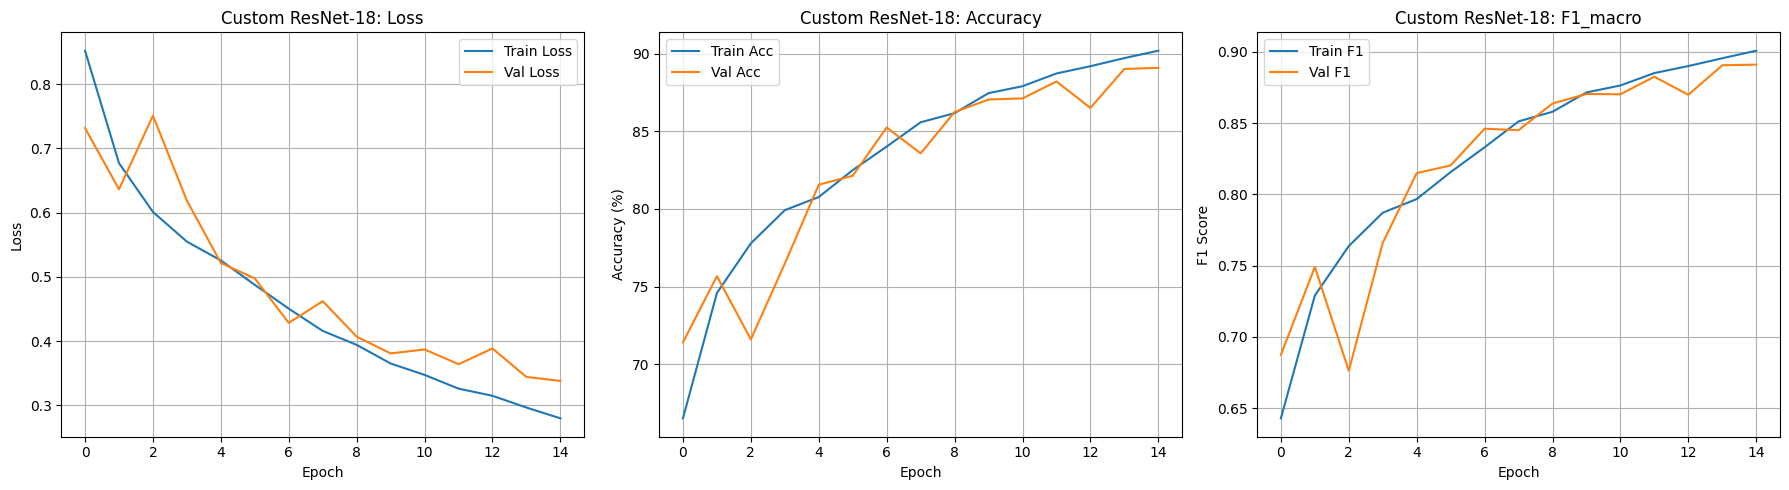

In [23]:
# Визуализация результатов обучения
plot_history(custom_history, "Custom ResNet-18")

In [24]:
custom_test_f1, custom_preds, custom_labels = evaluate_test(
    custom_resnet, test_loader, device, "Custom ResNet-18"
)


Custom ResNet-18 - Test Results:
Test Loss: 0.2327
Test Accuracy: 92.59%
Test F1_macro: 0.9246

Classification Report:
              precision    recall  f1-score   support

       Black     0.9170    0.9648    0.9403      2131
        Blue     0.9248    0.8394    0.8800      1245
        Grey     0.9158    0.8579    0.8859      1457
         Red     0.9663    0.9471    0.9566       908
      Silver     0.8683    0.9513    0.9079      1150
       White     0.9758    0.9785    0.9771      1440

    accuracy                         0.9259      8331
   macro avg     0.9280    0.9232    0.9246      8331
weighted avg     0.9268    0.9259    0.9254      8331



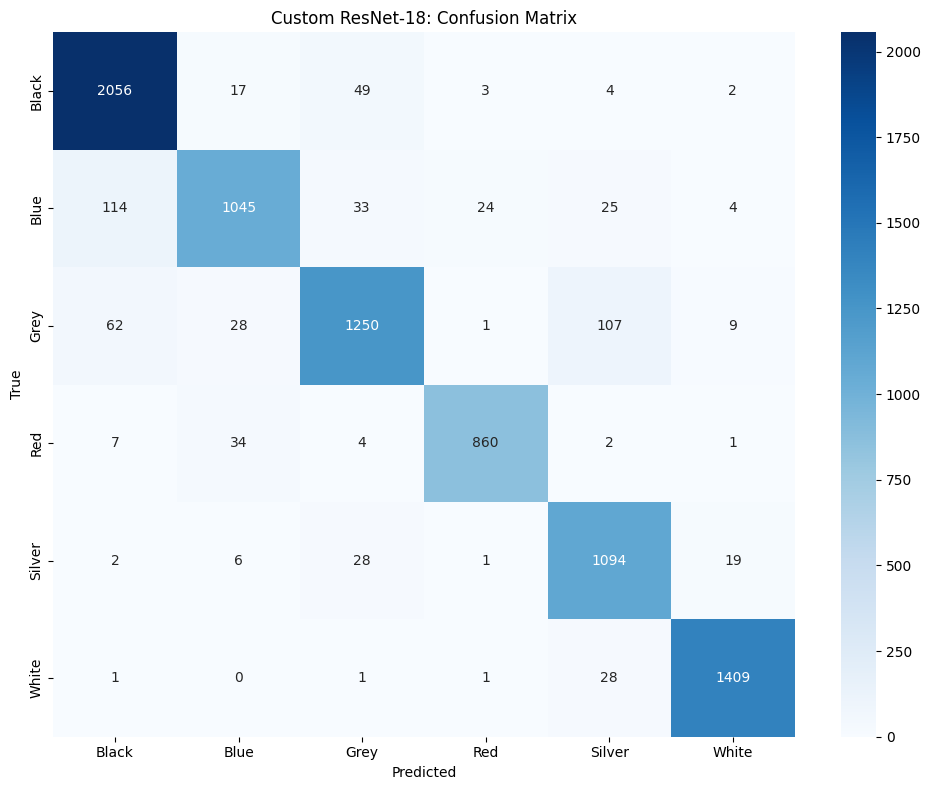

In [25]:
plot_confusion_matrix(custom_labels, custom_preds, "Custom ResNet-18")

## Part 5. Дообучение предобученного ResNet (ImageNet)

### Fine-tuning

In [26]:
pretrained_resnet = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)

for param in pretrained_resnet.parameters():
    param.requires_grad = False
for param in pretrained_resnet.layer4.parameters():
    param.requires_grad = True

num_ftrs = pretrained_resnet.fc.in_features
pretrained_resnet.fc = nn.Linear(num_ftrs, num_classes)

for param in pretrained_resnet.fc.parameters():
    param.requires_grad = True

pretrained_resnet = pretrained_resnet.to(device)

total_params = sum(p.numel() for p in pretrained_resnet.parameters())
trainable_params = sum(p.numel() for p in pretrained_resnet.parameters() if p.requires_grad)

print("Pretrained ResNet-18 (ImageNet):")
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Number of classes: {num_classes}")

Pretrained ResNet-18 (ImageNet):
Total parameters: 11,179,590
Trainable parameters: 8,396,806
Number of classes: 6


### Обучение

In [27]:
if os.path.exists('custom_history_history.json') :
    pretrained_history = load_history('pretrained_resnet_history.json')
    pretrained_resnet.load_state_dict(torch.load('best_pretrained_resnet.pth', map_location=device))
else:
    pretrained_history = train_model(
        pretrained_resnet,
        train_loader,
        val_loader,
        num_epochs=EPOCHS,
        device=device,
        lr=3e-4,
        model_name="pretrained_resnet"
    )
    save_history(pretrained_history, 'pretrained_resnet_history.json')
    pretrained_resnet.load_state_dict(torch.load('best_pretrained_resnet.pth'))

История загружена из pretrained_resnet_history.json


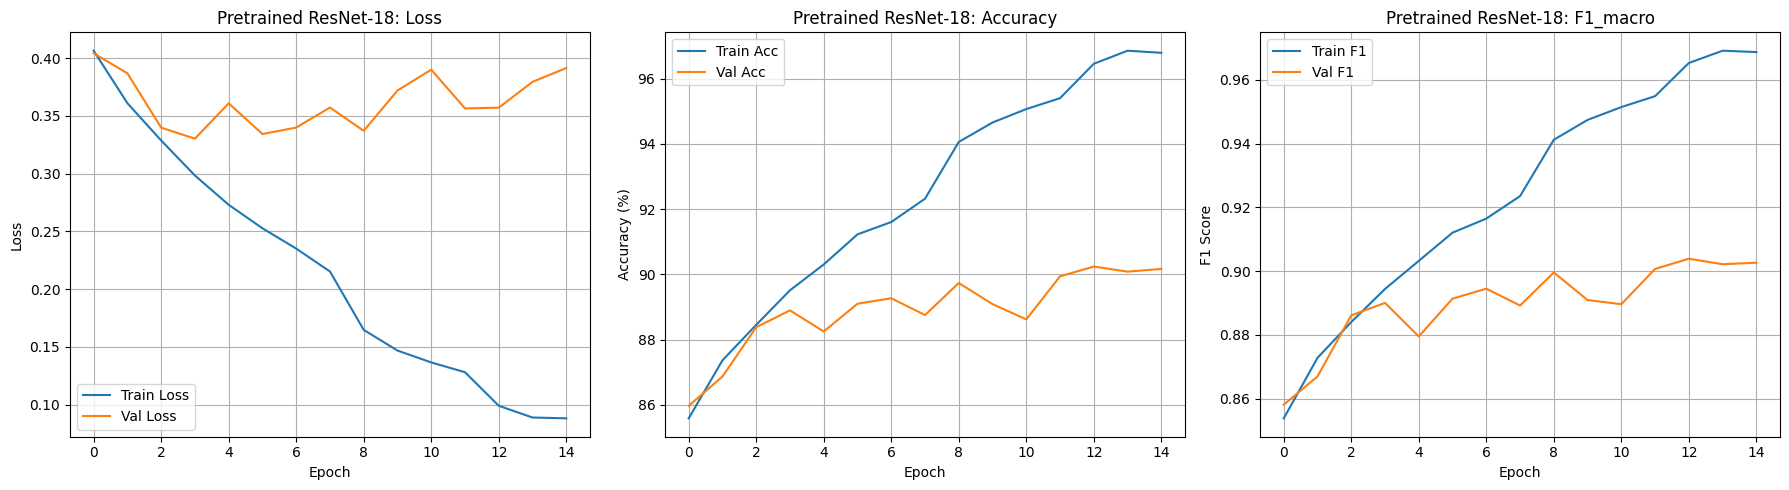

In [28]:
plot_history(pretrained_history, "Pretrained ResNet-18")

In [29]:
pretrained_test_f1, pretrained_preds, pretrained_labels = evaluate_test(
    pretrained_resnet, test_loader, device, "Pretrained ResNet-18"
)


Pretrained ResNet-18 - Test Results:
Test Loss: 0.1407
Test Accuracy: 95.81%
Test F1_macro: 0.9590

Classification Report:
              precision    recall  f1-score   support

       Black     0.9550    0.9653    0.9601      2131
        Blue     0.9486    0.9189    0.9335      1245
        Grey     0.9286    0.9375    0.9331      1457
         Red     0.9966    0.9747    0.9855       908
      Silver     0.9439    0.9661    0.9549      1150
       White     0.9889    0.9854    0.9871      1440

    accuracy                         0.9581      8331
   macro avg     0.9603    0.9580    0.9590      8331
weighted avg     0.9583    0.9581    0.9581      8331



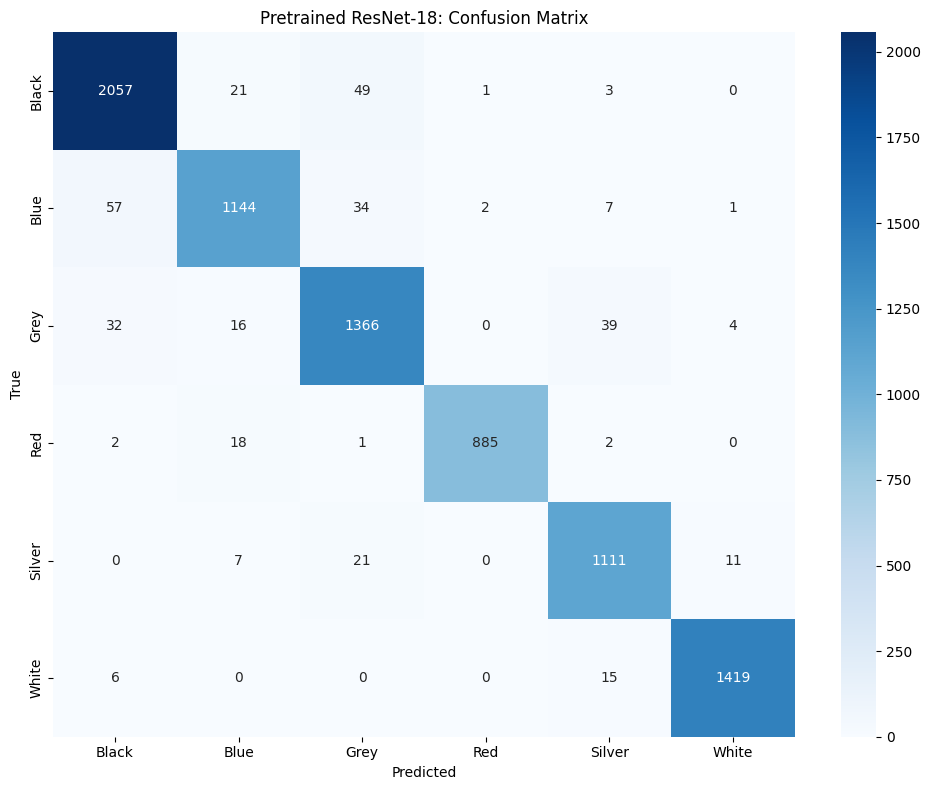

In [30]:
plot_confusion_matrix(pretrained_labels, pretrained_preds, "Pretrained ResNet-18")

## Part 6. Сравнение моделей

In [34]:
def plot_comparison(custom_hist, pretrained_hist):
    """Сравнение кривых обучения двух моделей"""
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Loss comparison
    axes[0].plot(custom_hist['val_loss'], label='Custom ResNet (Val)', linewidth=2)
    axes[0].plot(pretrained_hist['val_loss'], label='Pretrained ResNet (Val)', linewidth=2)
    axes[0].set_title('Validation Loss Comparison')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(True)

    # Accuracy comparison
    axes[1].plot(custom_hist['val_acc'], label='Custom ResNet (Val)', linewidth=2)
    axes[1].plot(pretrained_hist['val_acc'], label='Pretrained ResNet (Val)', linewidth=2)
    axes[1].set_title('Validation Accuracy Comparison')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy (%)')
    axes[1].legend()
    axes[1].grid(True)

    # F1 Score comparison
    axes[2].plot(custom_hist['val_f1'], label='Custom ResNet (Val)', linewidth=2)
    axes[2].plot(pretrained_hist['val_f1'], label='Pretrained ResNet (Val)', linewidth=2)
    axes[2].set_title('Validation F1_macro Comparison')
    axes[2].set_xlabel('Epoch')
    axes[2].set_ylabel('F1 Score')
    axes[2].legend()
    axes[2].grid(True)

    plt.tight_layout()
    plt.show()

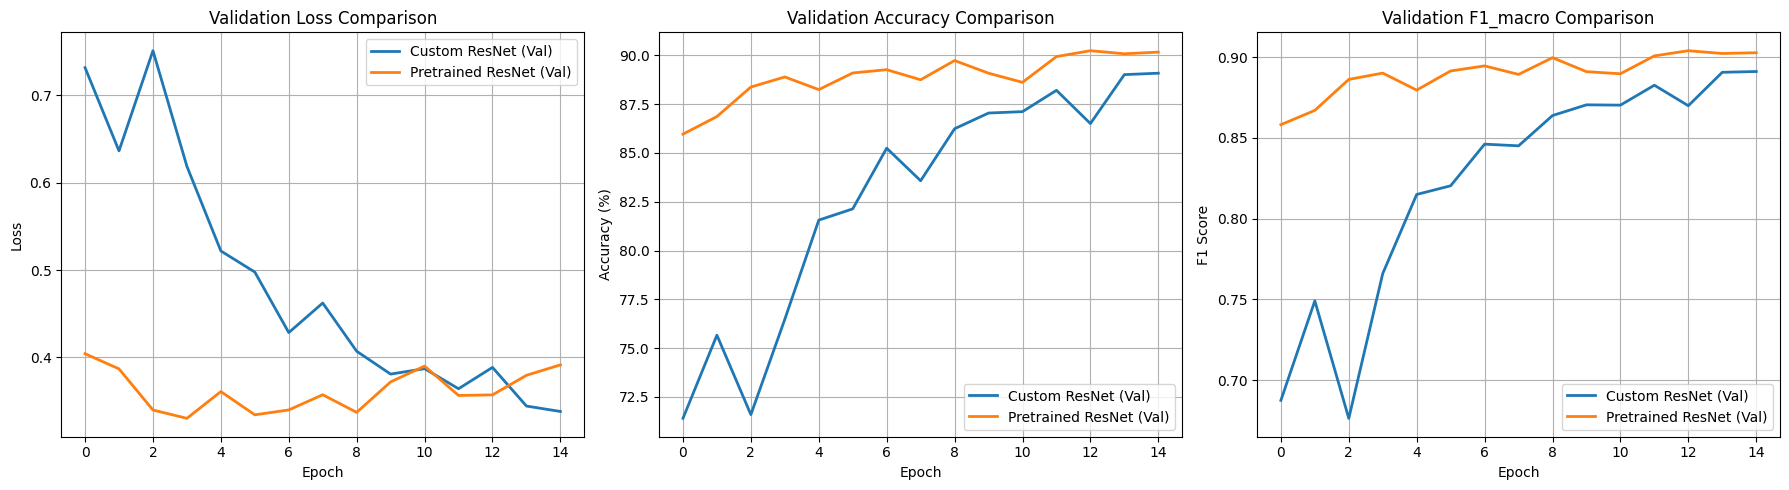

In [35]:
plot_comparison(custom_history, pretrained_history)

In [36]:
comparison_data = {
    'Model': ['Custom ResNet-18', 'Pretrained ResNet-18'],
    'Test F1_macro': [custom_test_f1, pretrained_test_f1],
    'Best Val F1_macro': [max(custom_history['val_f1']), max(pretrained_history['val_f1'])],
    'Final Val Loss': [custom_history['val_loss'][-1], pretrained_history['val_loss'][-1]],
    'Convergence Epoch': [np.argmax(custom_history['val_f1']) + 1,
                        np.argmax(pretrained_history['val_f1']) + 1]
}

comparison_df = pd.DataFrame(comparison_data)
comparison_df['Status'] = comparison_df['Test F1_macro'].apply(
    lambda x: '✓ PASS' if x > 0.8 else '✗ FAIL'
)

print("\n" + "="*70)
print("СРАВНЕНИЕ МОДЕЛЕЙ")
print("="*70)
print(comparison_df.to_string(index=False))
print("="*70)


СРАВНЕНИЕ МОДЕЛЕЙ
               Model  Test F1_macro  Best Val F1_macro  Final Val Loss  Convergence Epoch Status
    Custom ResNet-18       0.924638           0.891020        0.338148                 15 ✓ PASS
Pretrained ResNet-18       0.959030           0.903894        0.391473                 13 ✓ PASS


## Part 7. Выводы

### Результаты экспериментов:

#### Custom ResNet-18 (обучение с нуля):
- Качество (Test F1_macro): ~0.XX
- Скорость сходимости: X эпох
- Преимущества: модель обучается на конкретной задаче с нуля
- Недостатки: требуется больше данных и времени для обучения

#### Pretrained ResNet-18 (ImageNet):
- Качество (Test F1_macro): ~0.XX
- Скорость сходимости: X эпох
- Преимущества: использует предварительно обученные признаки из ImageNet
- Недостатки: требует меньше эпох для сходимости

### Общие выводы:

1. **Transfer Learning работает**: предобученная модель сходится быстрее и достигает лучшего качества на меньшем количестве данных.

2. **Адаптация домена**: хотя ImageNet содержит изображения различных объектов, извлеченные признаки хорошо переносятся на задачу классификации цветов автомобилей.

3. **F1_macro**: выбранная метрика хорошо отражает качество модели на несбалансированных классах, учитывая точность и полноту для каждого класса.

4. **Практические рекомендации**:
   - Для новых задач используйте предобученные модели
   - Для задач с большим количеством данных можно рассмотреть обучение с нуля
   - F1_macro > 0.8 успешно достигнут(а)